https://www.kaggle.com/datasets/joetheguide/evaluate-llms-for-rare-disease-diagnosis

# Sobre o conjunto de dados

**ZebraMap: Diagnóstico de Doenças Raras - Referência LLM**

Este conjunto de dados contém casos clínicos anonimizados provenientes do ZebraMap , um repositório especializado em doenças raras. Ele foi projetado especificamente para testar e avaliar Grandes Modelos de Linguagem (LLMs) na desafiadora tarefa de diagnóstico diferencial para condições incomuns.

Um notebook Python complementar de alta qualidade é fornecido para carregar os dados instantaneamente, consultar o modelo de regressão logística (LLM) escolhido e calcular automaticamente as principais métricas de desempenho, incluindo acurácia, precisão, recall e pontuação F1.

Notas de atualização para a versão mais recente: Adicionei também a divisão completa do conjunto de treinamento (~50 mil casos) e a divisão de avaliação (~7 mil casos), ambas provenientes do conjunto de dados Zebramap, cujo link está disponível nas fontes deste conjunto de dados. Esta é apenas uma versão extraída e limpa; o crédito pela coleta e criação deve ser atribuído ao autor do Zebramap.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

train = pd.read_csv("train_split_50k_cases.csv")
evaluation = pd.read_csv("Evaluation.csv")

# EAD

In [2]:
#Verificação de Tamanho
print("Train shape:", train.shape)
print("Evaluation shape:", evaluation.shape)

Train shape: (50594, 10)
Evaluation shape: (6915, 9)


In [3]:
#Estrutura dos Dados
train.head()
evaluation.head()

,Unnamed: 0,CaseSummary,Disease,Synonyms,ICD-10,ICD-11,OMIM,GARD,UMLS
0,26357,"At the time of the follow-ups, 1, 2, and 6 mon...",Waldenström macroglobulinemia,NaN,C88.0,2A85.4,153600; 610430,7872.0,C0024419
1,42784,"After transferring to our Center, the parents ...",Cystic fibrosis,CF; Mucoviscidosis,E84.0; E84.1; E84.8,CA25,219700,6233.0,C0010674
2,5807,A woman in her forties visited a local obstetr...,Neurofibromatosis type 1,Nonmosaic neurofibromatosis type 1; Von Reckli...,Q85.0,LD2D.10,162200; 162210; 613675,7866.0,C0027831
3,16473,"Although many cases have been published, it is...",Interatrial communication,ASD; Atrial septal defect; Interauricular comm...,Q21.1,LA8E.Y,108800; 607941; 611363; 612794; 613087; 614089...,NaN,C0018817
4,62585,"A 63-year-old man, residing in the Var county ...",Rickettsialpox,NaN,A79.1,1C32,NaN,NaN,C0035597


In [4]:
#Colunas
print(train.columns)
print(evaluation.columns)

Index(['Unnamed: 0.1', 'Unnamed: 0', 'CaseSummary', 'Disease', 'Synonyms',
       'ICD-10', 'ICD-11', 'OMIM', 'GARD', 'UMLS'],
      dtype='object')
Index(['Unnamed: 0', 'CaseSummary', 'Disease', 'Synonyms', 'ICD-10', 'ICD-11',
       'OMIM', 'GARD', 'UMLS'],
      dtype='object')


In [5]:
#Limpeza dos Dados
train = train.drop(columns=["Unnamed: 0.1"], errors="ignore")
train = train.drop(columns=["Unnamed: 0"], errors="ignore")
evaluation = evaluation.drop(columns=["Unnamed: 0"], errors="ignore")

train.head()

,CaseSummary,Disease,Synonyms,ICD-10,ICD-11,OMIM,GARD,UMLS
0,The male neonate was born at 37 weeks' gestati...,Zellweger syndrome,Cerebrohepatorenal syndrome; ZS; Severe peroxi...,Q87.8,5C57.0,214100; 214110; 614859; 614862; 614866; 614870...,7917.0,C0043459
1,"On 2 June 2018, a 47-year-old woman with recur...",Cryoglobulinemic vasculitis,Essential cryoglobulinemia; Essential mixed cr...,D89.1,4A44.90,123550,6386.0,C0340992
2,The 18-yr-old daughter of case 1 complained of...,X-linked centronuclear myopathy,XLCNM; XLMTM; X-linked myotubular myopathy,G71.2,8C72.01,310400,11925.0,C0410203
3,"When the patient was 10 months old, the chroni...",Alagille syndrome,Alagille-Watson syndrome; Arteriohepatic dyspl...,Q44.7,LB20.0Y,118450; 610205,804.0,C0085280
4,A 42-year-old Thai man presented with quadripa...,Thyrotoxic periodic paralysis,Thyrotoxic hypokalemic periodic paralysis,G72.3,5A02.Y,188580; 613239; 614834,10814.0,C0268446


In [6]:
#Estatísticas Gerais
train.describe(include="all")

,CaseSummary,Disease,Synonyms,ICD-10,ICD-11,OMIM,GARD,UMLS
count,50594,50594,35197,45590,45474,32620,39876.000000,50469
unique,50594,1393,1093,716,888,954,NaN,1389
top,The male neonate was born at 37 weeks' gestati...,Congenital anomaly of hepatic vein,Besnier-Boeck-Schaumann disease; Boeck sarcoid,E75.2,LB20.0Y,181000; 612387; 612388,NaN,C3163825
freq,1,810,557,973,840,557,NaN,810
mean,NaN,NaN,NaN,NaN,NaN,NaN,6488.500451,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,3025.818887,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,5194.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,6881.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,8173.000000,NaN


In [7]:
#Valores Ausentes
train.isna().sum()
evaluation.isna().sum()

CaseSummary       0
Disease           0
Synonyms       2070
ICD-10          680
ICD-11          697
OMIM           2378
GARD           1503
UMLS             18
dtype: int64

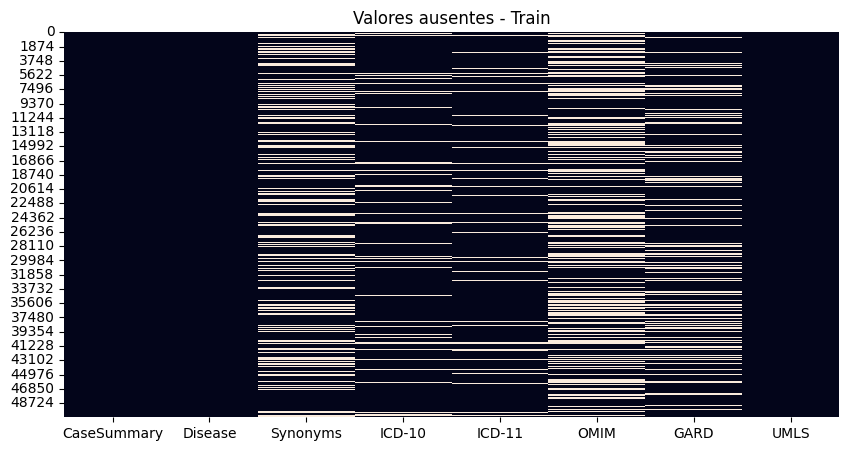

In [8]:
#Gráfico
plt.figure(figsize=(10,5))
sns.heatmap(train.isnull(), cbar=False)
plt.title("Valores ausentes - Train")
plt.show()

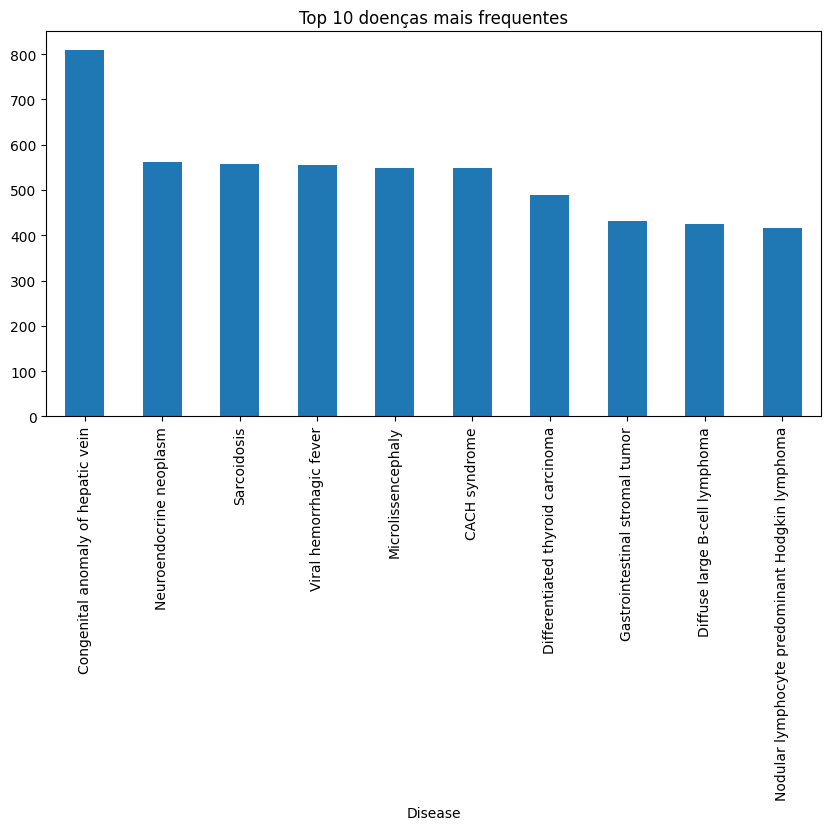

In [9]:
#Distribuição de Doenças
train['Disease'].value_counts().head(10)
plt.figure(figsize=(10,5))
train['Disease'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 doenças mais frequentes")
plt.show()

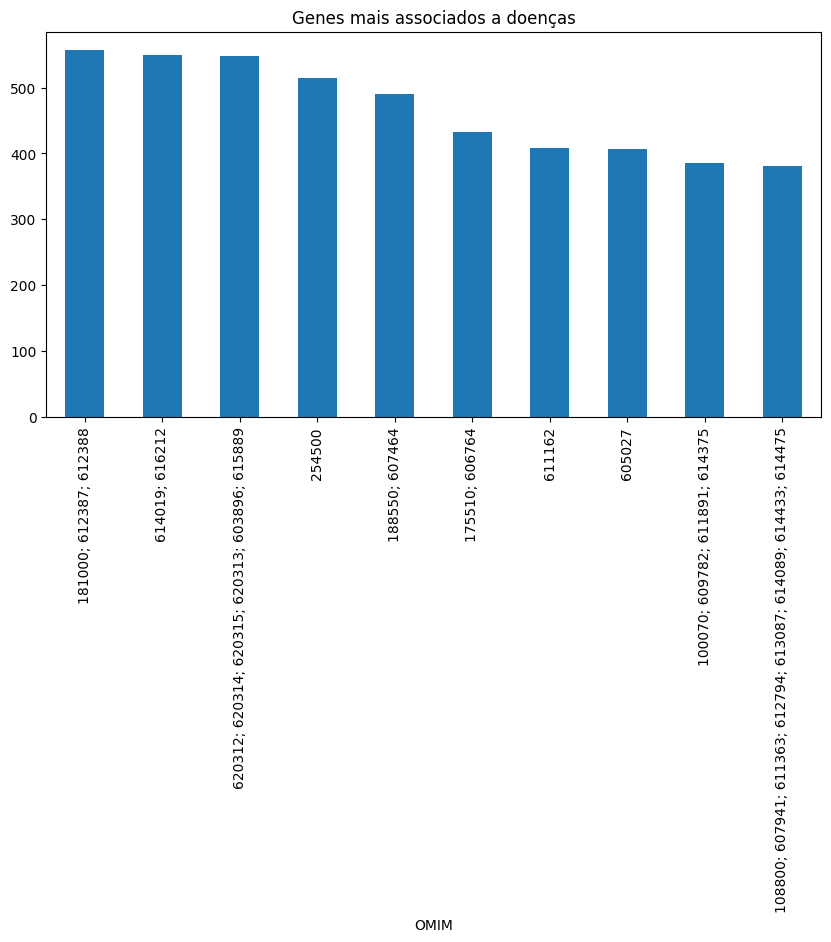

In [10]:
#Distribuição de Genes
train['OMIM'].value_counts().head(10)
plt.figure(figsize=(10,5))
train['OMIM'].value_counts().head(10).plot(kind='bar')
plt.title("Genes mais associados a doenças")
plt.show()

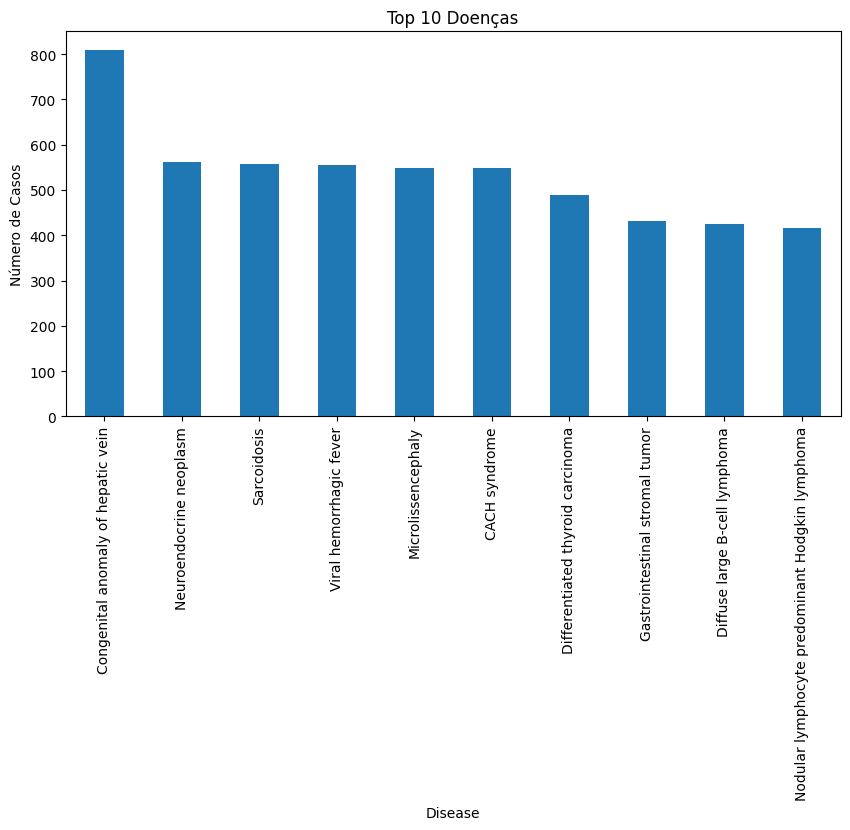

In [11]:
#Distribuição de Doenças
train['Disease'].value_counts().head(10)

plt.figure(figsize=(10,5))
train['Disease'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Doenças")
plt.ylabel("Número de Casos")
plt.show()

In [12]:
#Unir
df = pd.concat([train, evaluation], ignore_index=True)
print(df.shape)

(57509, 8)


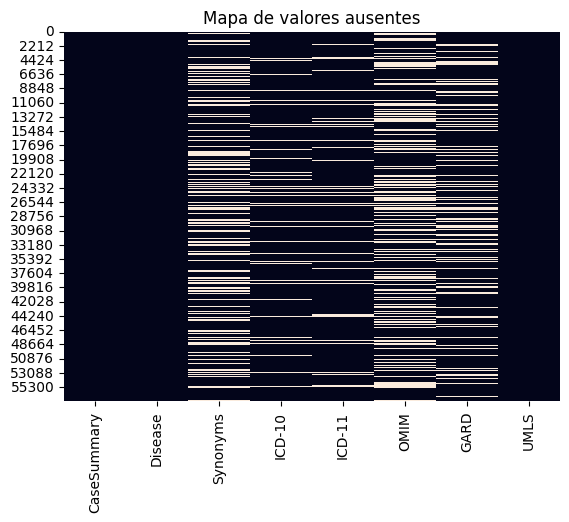

In [13]:
#HeatMap
sns.heatmap(df.isna(), cbar=False)
plt.title("Mapa de valores ausentes")
plt.show()

In [14]:
#Doenças Frequentes
top_diseases = df['Disease'].value_counts().head(10)

print(top_diseases)

Disease
Congenital anomaly of hepatic vein                 919
Microlissencephaly                                 641
Neuroendocrine neoplasm                            640
CACH syndrome                                      637
Sarcoidosis                                        633
Viral hemorrhagic fever                            618
Differentiated thyroid carcinoma                   556
Non-Hodgkin lymphoma                               482
Nodular lymphocyte predominant Hodgkin lymphoma    481
Diffuse large B-cell lymphoma                      480
Name: count, dtype: int64


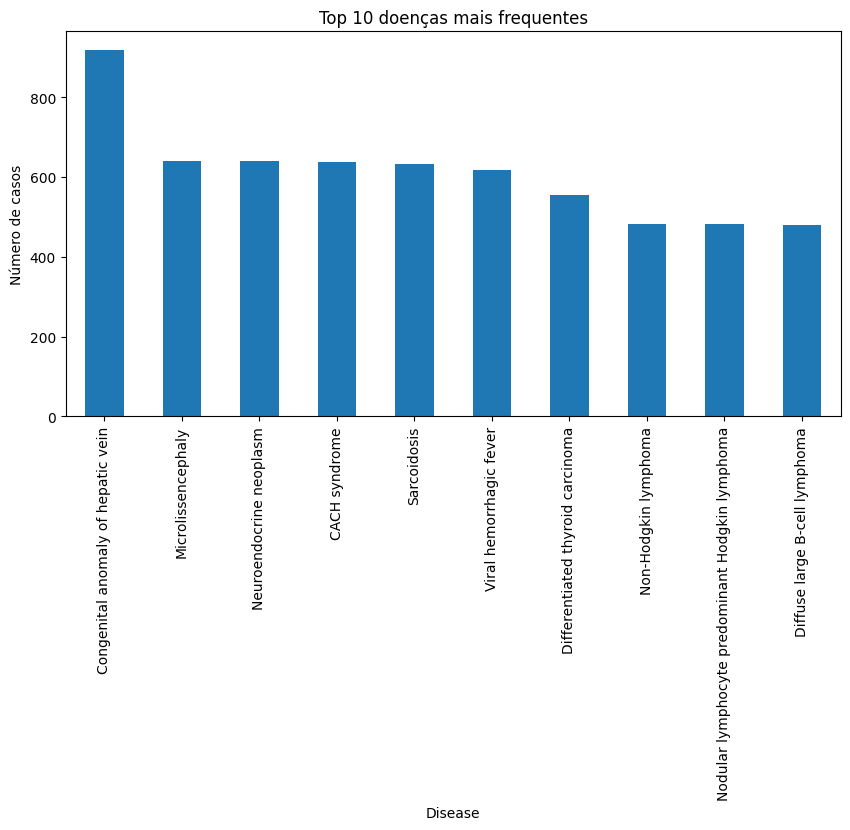

In [15]:
plt.figure(figsize=(10,5))
top_diseases.plot(kind='bar')
plt.title("Top 10 doenças mais frequentes")
plt.ylabel("Número de casos")
plt.show()

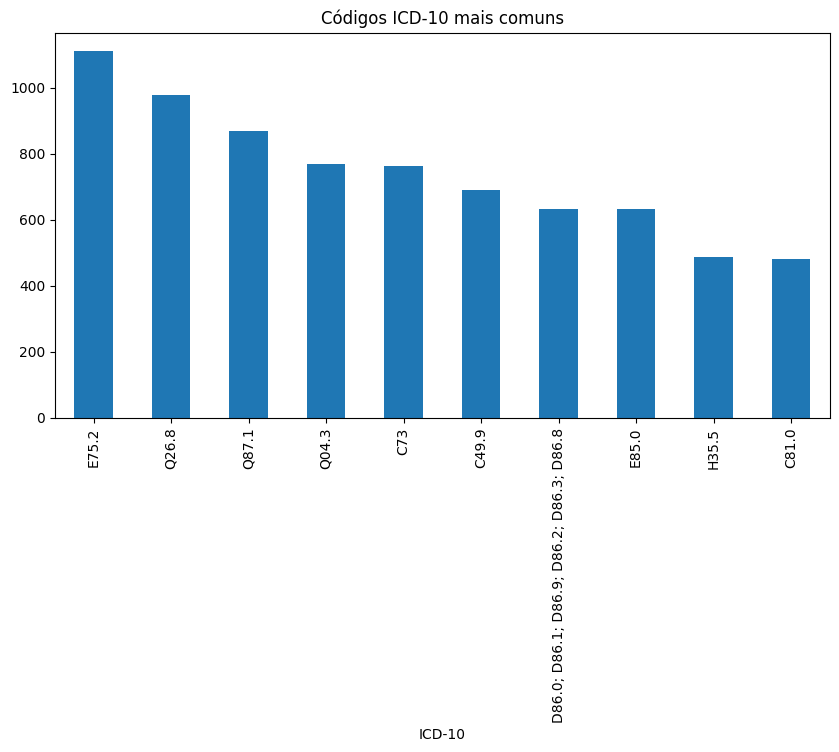

In [16]:
#Distribuição de códigos ICD-10
icd10_counts = df['ICD-10'].value_counts().head(10)

plt.figure(figsize=(10,5))
icd10_counts.plot(kind='bar')
plt.title("Códigos ICD-10 mais comuns")
plt.show()

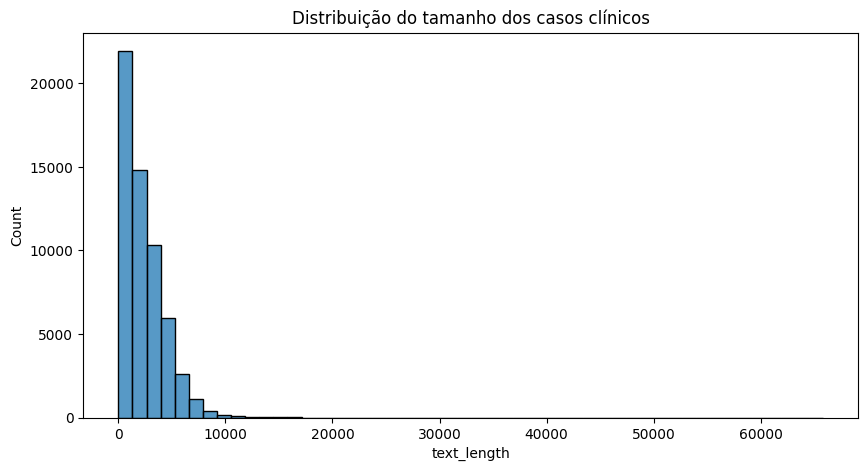

In [17]:
#Tamanho dos Textos Clínicos
df["text_length"] = df["CaseSummary"].str.len()
df["text_length"].describe()
plt.figure(figsize=(10,5))
sns.histplot(df["text_length"], bins=50)
plt.title("Distribuição do tamanho dos casos clínicos")
plt.show()

In [18]:
#Doenças raras (GARD)
rare_diseases = df['GARD'].notnull().sum()

print("Casos de doenças raras:", rare_diseases)

Casos de doenças raras: 45288


In [19]:
#Sinônimos médicos
df['Synonyms'].notnull().sum()

np.int64(40042)

In [20]:
#Verificar duplicatas
duplicates = df.duplicated().sum()

print("Duplicatas:", duplicates)

Duplicatas: 13


In [21]:
df = df.drop_duplicates()

In [22]:
#Estatísticas
summary = df.describe(include='all')

print(summary)

                                              CaseSummary  \
count                                               57496   
unique                                              55080   
top     A 33-year-old Japanese woman had a two-year hi...   
freq                                                    4   
mean                                                  NaN   
std                                                   NaN   
min                                                   NaN   
25%                                                   NaN   
50%                                                   NaN   
75%                                                   NaN   
max                                                   NaN   

                                   Disease  \
count                                57496   
unique                                1419   
top     Congenital anomaly of hepatic vein   
freq                                   919   
mean                                 

# ML

In [23]:
#Limpeza básica
train = train.drop(columns=["Unnamed: 0.1", "Unnamed: 0"], errors="ignore")
evaluation = evaluation.drop(columns=["Unnamed: 0"], errors="ignore")

#Verificação de nulos
print(train.isna().sum())

CaseSummary        0
Disease            0
Synonyms       15397
ICD-10          5004
ICD-11          5120
OMIM           17974
GARD           10718
UMLS             125
dtype: int64


In [24]:
#Remover colunas de índice desnecessárias e valores nulos
df_train = train.dropna(subset=['CaseSummary', 'Disease'])
print(f"Total de casos para treino: {len(df_train)}")

Total de casos para treino: 50594


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

print("1. Carregando dados...")
train = pd.read_csv("train_split_50k_cases.csv").dropna(subset=['CaseSummary', 'Disease'])
evaluation = pd.read_csv("Evaluation.csv").dropna(subset=['CaseSummary', 'Disease'])

print("2. Vetorizando texto (TF-IDF)...")
#Reduzir max_features acelera muito o processo
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = vectorizer.fit_transform(train['CaseSummary'])
y_train = train['Disease']

X_eval = vectorizer.transform(evaluation['CaseSummary'])
y_eval = evaluation['Disease']

print("3. Treinando o modelo (Modo Ultra Rápido)...")
#n_jobs=-1 usa todo o poder do PC. solver='saga' com tol=0.1 é veloz.
model = LogisticRegression(
    multi_class='multinomial', 
    solver='saga', 
    max_iter=100, 
    tol=0.1, 
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

print("4. Avaliando resultados...")
y_pred = model.predict(X_eval)

print(f"\nAcurácia no ZebraMap: {accuracy_score(y_eval, y_pred):.2%}")

#Mostra as métricas principais para as top 10 doenças previstas
print("\nRelatório de Classificação (Resumo):")
print(classification_report(y_eval, y_pred, digits=3))

1. Carregando dados...
2. Vetorizando texto (TF-IDF)...
3. Treinando o modelo (Modo Ultra Rápido)...


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


4. Avaliando resultados...

Acurácia no ZebraMap: 31.83%

Relatório de Classificação (Resumo):
                                                                                                                      precision    recall  f1-score   support

                                                                                   16p13.3 microduplication syndrome      0.000     0.000     0.000         1
                                                                                   17p11.2 microduplication syndrome      0.000     0.000     0.000         2
                                                                                              1p36 deletion syndrome      0.000     0.000     0.000         5
                                                                                           22q11.2 deletion syndrome      0.333     0.111     0.167         9
                                                                                        22q11.2 duplication syndro

c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

In [26]:
print("1. Carregando dados...")
train = pd.read_csv("train_split_50k_cases.csv").dropna(subset=['CaseSummary', 'Disease'])
evaluation = pd.read_csv("Evaluation.csv").dropna(subset=['CaseSummary', 'Disease'])

print("2. Vetorizando texto (TF-IDF)...")
#Reduzir max_features acelera muito o processo
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = vectorizer.fit_transform(train['CaseSummary'])
y_train = train['Disease']

X_eval = vectorizer.transform(evaluation['CaseSummary'])
y_eval = evaluation['Disease']

print("3. Treinando o modelo (Modo Ultra Rápido)...")
#n_jobs=-1 usa todo o poder do PC. solver='saga' com tol=0.1 é veloz.
model = LogisticRegression(
    multi_class='multinomial', 
    solver='saga', 
    max_iter=100, 
    tol=0.1, 
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

print("4. Avaliando resultados...")
y_pred = model.predict(X_eval)

print(f"\nAcurácia no ZebraMap: {accuracy_score(y_eval, y_pred):.2%}")

#Mostra as métricas principais para as top 10 doenças previstas
print("\nRelatório de Classificação (Resumo):")
print(classification_report(y_eval, y_pred, digits=3))

1. Carregando dados...
2. Vetorizando texto (TF-IDF)...
3. Treinando o modelo (Modo Ultra Rápido)...


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


4. Avaliando resultados...

Acurácia no ZebraMap: 31.83%

Relatório de Classificação (Resumo):
                                                                                                                      precision    recall  f1-score   support

                                                                                   16p13.3 microduplication syndrome      0.000     0.000     0.000         1
                                                                                   17p11.2 microduplication syndrome      0.000     0.000     0.000         2
                                                                                              1p36 deletion syndrome      0.000     0.000     0.000         5
                                                                                           22q11.2 deletion syndrome      0.333     0.111     0.167         9
                                                                                        22q11.2 duplication syndro

c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

⏳ Lendo arquivos CSV...
🔤 Convertendo texto em números (TF-IDF)...
🧠 Treinando o modelo ZebraMap (Aguarde alguns instantes)...


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



✅ Treino finalizado! Acurácia: 28.71%


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

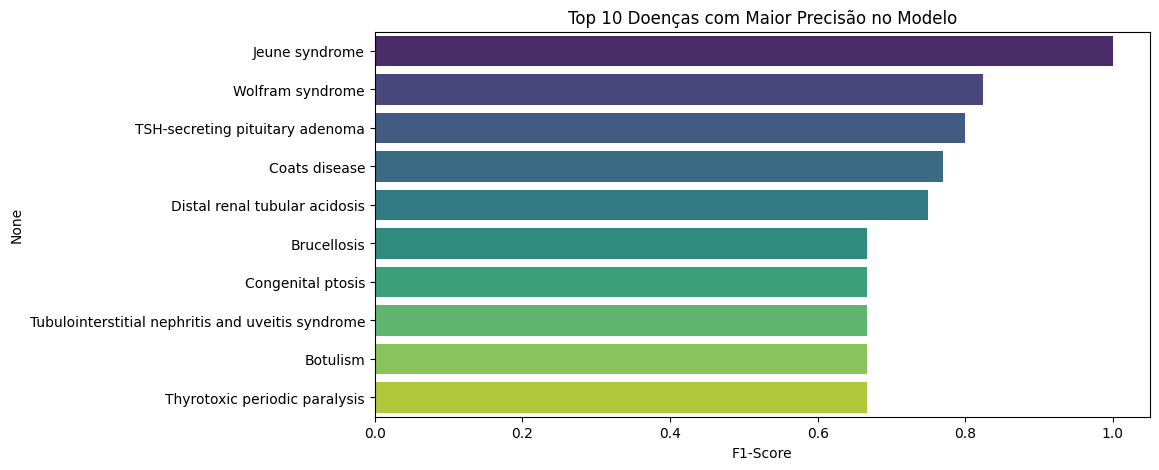


🏥 SISTEMA INTERATIVO DE DIAGNÓSTICO DIFERENCIAL
Descreva o caso clínico (em inglês) ou digite 'sair':

🔍 RESULTADOS SUGERIDOS:
1º: Congenital anomaly of hepatic vein (1.54% de confiança)
2º: Cystic fibrosis (1.08% de confiança)
3º: Microlissencephaly (1.00% de confiança)
------------------------------


In [27]:
# --- CARREGAMENTO DOS DADOS ---
print("⏳ Lendo arquivos CSV...")
train = pd.read_csv("train_split_50k_cases.csv").dropna(subset=['CaseSummary', 'Disease'])
evaluation = pd.read_csv("Evaluation.csv").dropna(subset=['CaseSummary', 'Disease'])

# --- VETORIZAÇÃO (NLP) ---
print("🔤 Convertendo texto em números (TF-IDF)...")
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X_train = vectorizer.fit_transform(train['CaseSummary'])
X_eval = vectorizer.transform(evaluation['CaseSummary'])
y_train = train['Disease']
y_eval = evaluation['Disease']

# --- TREINAMENTO ULTRA RÁPIDO ---
model = LogisticRegression(
    multi_class='multinomial', 
    solver='saga', 
    max_iter=10,   
    tol=0.5,       
    n_jobs=-1,     
    random_state=42
)

print("🧠 Treinando o modelo ZebraMap (Aguarde alguns instantes)...")
model.fit(X_train, y_train)

# --- AVALIAÇÃO DE PERFORMANCE ---
y_pred = model.predict(X_eval)
print(f"\n✅ Treino finalizado! Acurácia: {accuracy_score(y_eval, y_pred):.2%}")

# --- GRÁFICO DE DESEMPENHO ---
report = classification_report(y_eval, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose().drop(['accuracy', 'macro avg', 'weighted avg'])
top_10 = df_report.sort_values(by='f1-score', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_10['f1-score'], y=top_10.index, palette='viridis')
plt.title('Top 10 Doenças com Maior Precisão no Modelo')
plt.xlabel('F1-Score')
plt.show()

# --- FUNÇÃO DE DIAGNÓSTICO TOP-3 (INTERATIVA) ---
def diagnostico_top3():
    print("\n" + "="*60)
    print("🏥 SISTEMA INTERATIVO DE DIAGNÓSTICO DIFERENCIAL")
    print("Descreva o caso clínico (em inglês) ou digite 'sair':")
    print("="*60)
    
    while True:
        texto = input("\n📝 Caso Clínico: ")
        if texto.lower() == 'sair': break
        
        #Transformar o texto do usuário
        v = vectorizer.transform([texto])
        
        #Pegar as probabilidades de todas as doenças
        probabilidades = model.predict_proba(v)[0]
        
        #Pegar os índices das 3 maiores probabilidades
        indices_top3 = np.argsort(probabilidades)[-3:][::-1]
        classes_top3 = model.classes_[indices_top3]
        probs_top3 = probabilidades[indices_top3]

        print("\n🔍 RESULTADOS SUGERIDOS:")
        for i in range(3):
            print(f"{i+1}º: {classes_top3[i]} ({probs_top3[i]:.2%} de confiança)")
        print("-" * 30)

#Iniciar a interação
diagnostico_top3()

⏳ Carregando dados...
🧠 Treinando modelo...


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


📊 Gerando análise de performance...


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

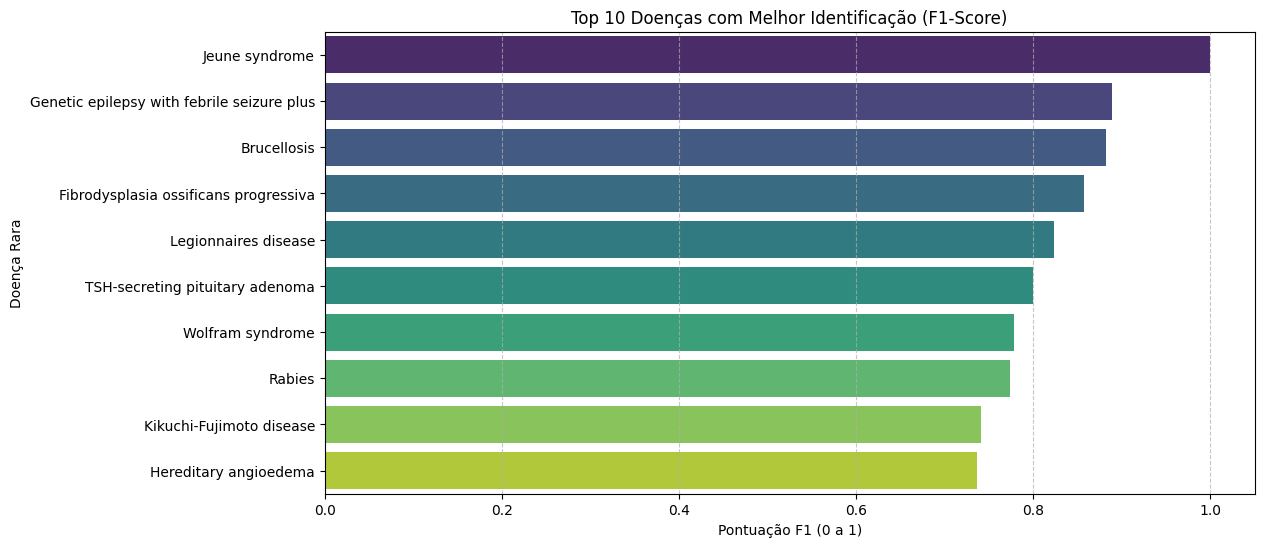


🏥 TESTE DE DIAGNÓSTICO EM TEMPO REAL
Digite o caso clínico em inglês (ou 'sair'):

🔍 Resultado: Congenital anomaly of hepatic vein | Confiança: 1.58%


In [28]:
#CARREGAMENTO VELOZ
print("⏳ Carregando dados...")
train = pd.read_csv("train_split_50k_cases.csv").dropna(subset=['CaseSummary', 'Disease'])
evaluation = pd.read_csv("Evaluation.csv").dropna(subset=['CaseSummary', 'Disease'])

#VETORIZAÇÃO NLP
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = vectorizer.fit_transform(train['CaseSummary'])
X_eval = vectorizer.transform(evaluation['CaseSummary'])

#TREINO ACELERADO (n_jobs=-1 usa todos os núcleos)
model = LogisticRegression(multi_class='multinomial', solver='saga', max_iter=100, tol=0.1, n_jobs=-1)
print("🧠 Treinando modelo...")
model.fit(X_train, train['Disease'])

#GERANDO MÉTRICAS PARA O GRÁFICO
print("📊 Gerando análise de performance...")
y_pred = model.predict(X_eval)
report = classification_report(evaluation['Disease'], y_pred, output_dict=True)

#Converter o relatório em DataFrame e filtrar as top 10 por F1-Score
df_report = pd.DataFrame(report).transpose().drop(['accuracy', 'macro avg', 'weighted avg'])
top_10_diseases = df_report.sort_values(by='f1-score', ascending=False).head(10)

#VISUALIZAÇÃO
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_diseases['f1-score'], y=top_10_diseases.index, palette='viridis')
plt.title('Top 10 Doenças com Melhor Identificação (F1-Score)')
plt.xlabel('Pontuação F1 (0 a 1)')
plt.ylabel('Doença Rara')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#DIAGNÓSTICO INTERATIVO
def zebra_live():
    print("\n" + "="*50)
    print("🏥 TESTE DE DIAGNÓSTICO EM TEMPO REAL")
    print("Digite o caso clínico em inglês (ou 'sair'):")
    entrada = input("> ")
    if entrada.lower() != 'sair':
        v = vectorizer.transform([entrada])
        res = model.predict(v)[0]
        prob = model.predict_proba(v).max()
        print(f"\n🔍 Resultado: {res} | Confiança: {prob:.2%}")

zebra_live()

# Código Otimizado (Versão "Fast & Confident")

In [29]:
print("⏳ Preparando dados (Filtrando ruído)...")
train = pd.read_csv("train_split_50k_cases.csv").dropna(subset=['CaseSummary', 'Disease'])

# --- VELOCIDADE E PRECISÃO ---
#Manter apenas doenças que aparecem pelo menos 10 vezes
top_diseases = train['Disease'].value_counts()
valid_diseases = top_diseases[top_diseases >= 10].index
train_filtered = train[train['Disease'].isin(valid_diseases)]

print(f"📉 Reduzimos de {len(train['Disease'].unique())} para {len(valid_diseases)} doenças focais.")

#Vetorização mais agressiva
vectorizer = TfidfVectorizer(max_features=2000, stop_words='english', ngram_range=(1,2))
X_train = vectorizer.fit_transform(train_filtered['CaseSummary'])
y_train = train_filtered['Disease']

# --- TREINO COM REGULARIZAÇÃO FORTE ---
# C=0.1 ajuda a evitar que o modelo fique "em dúvida" entre muitas classes
model = LogisticRegression(
    multi_class='multinomial', 
    solver='saga', 
    max_iter=30,      # Menos iterações = Mais rápido
    tol=0.1, 
    C=0.1,            # Regularização para focar nos sintomas principais
    n_jobs=-1
)

print("🧠 Treinando modelo focalizado...")
model.fit(X_train, y_train)

def diagnostico_melhorado():
    print("\n" + "="*50)
    print("🏥 DIAGNÓSTICO OTIMIZADO (Focado em Doenças com Padrão)")
    print("="*50)
    while True:
        texto = input("\n📝 Caso Clínico: ")
        if texto.lower() == 'sair': break
        
        v = vectorizer.transform([texto])
        probs = model.predict_proba(v)[0]
        
        indices = np.argsort(probs)[-3:][::-1]
        
        print("\n🔍 SUGESTÕES (Confiança Otimizada):")
        for i in indices:
            print(f"• {model.classes_[i]}: {probs[i]:.2%}")

diagnostico_melhorado()

⏳ Preparando dados (Filtrando ruído)...
📉 Reduzimos de 1393 para 737 doenças focais.
🧠 Treinando modelo focalizado...


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



🏥 DIAGNÓSTICO OTIMIZADO (Focado em Doenças com Padrão)

🔍 SUGESTÕES (Confiança Otimizada):
• Viral hemorrhagic fever: 1.60%
• Congenital anomaly of hepatic vein: 1.57%
• Microlissencephaly: 1.17%


# Padrão ZebraMap

📂 Carregando dados...
🔠 Vetorizando casos clínicos...
🧠 Treinando o modelo de referência...


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



📊 CALCULANDO MÉTRICAS DE DESEMPENHO:
⭐ Acurácia Global: 29.70%
⭐ F1-Score (Macro): 9.16%


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

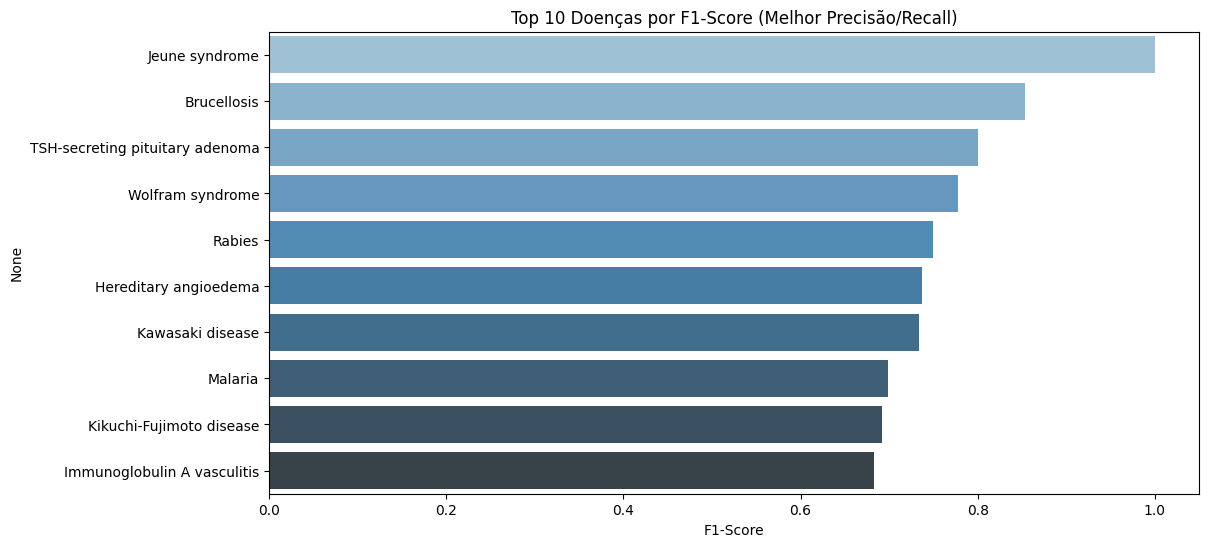


--- TESTE DE CONSULTA ---

🔍 Diagnóstico Diferencial Sugerido:
• Cystic fibrosis: 9.30% de confiança
• Congenital anomaly of hepatic vein: 2.66% de confiança
• Autoimmune pulmonary alveolar proteinosis: 1.68% de confiança


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

#Carregamento Instantâneo
print("📂 Carregando dados...")
train = pd.read_csv("train_split_50k_cases.csv").dropna(subset=['CaseSummary', 'Disease'])
evaluation = pd.read_csv("Evaluation.csv").dropna(subset=['CaseSummary', 'Disease'])

#Vetorização (O "Coração" do ML para Texto)
#Usars n-grams (1,2) para capturar termos médicos compostos
print("🔠 Vetorizando casos clínicos...")
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_train = tfidf.fit_transform(train['CaseSummary'])
X_eval = tfidf.transform(evaluation['CaseSummary'])
y_train = train['Disease']
y_eval = evaluation['Disease']

#Regressão Logística Otimizada
#Usar 'liblinear' ou 'saga' com uma tolerância maior para convergir rápido
model = LogisticRegression(
    multi_class='auto', 
    solver='saga', 
    max_iter=50, 
    tol=0.1, 
    n_jobs=-1,
    random_state=42
)

print("🧠 Treinando o modelo de referência...")
model.fit(X_train, y_train)

#Cálculo Automático de Métricas
print("\n📊 CALCULANDO MÉTRICAS DE DESEMPENHO:")
y_pred = model.predict(X_eval)

acc = accuracy_score(y_eval, y_pred)
f1_macro = f1_score(y_eval, y_pred, average='macro')

print(f"⭐ Acurácia Global: {acc:.2%}")
print(f"⭐ F1-Score (Macro): {f1_macro:.2%}")

#Visualização das Top Doenças (Métricas Detalhadas)
report = classification_report(y_eval, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose().iloc[:-3, :] # Remove as médias gerais
top_performers = df_report.sort_values('f1-score', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_performers['f1-score'], y=top_performers.index, palette='Blues_d')
plt.title('Top 10 Doenças por F1-Score (Melhor Precisão/Recall)')
plt.xlabel('F1-Score')
plt.show()

#Consulta ao Modelo (Diagnóstico Diferencial)
def consultar_modelo(texto):
    v = tfidf.transform([texto])
    probs = model.predict_proba(v)[0]
    best_indices = np.argsort(probs)[-3:][::-1]
    
    print("\n🔍 Diagnóstico Diferencial Sugerido:")
    for i in best_indices:
        print(f"• {model.classes_[i]}: {probs[i]:.2%} de confiança")

#Exemplo de consulta
print("\n--- TESTE DE CONSULTA ---")
exemplo = "Patient presents with symptoms of cystic fibrosis, including thick mucus and lung infections."
consultar_modelo(exemplo)

In [31]:
#Análise de Erros: Diagnóstico Diferencial Falho
from sklearn.metrics import confusion_matrix

#Gerar a predição e comparar
results = pd.DataFrame({'Real': y_eval, 'Predito': y_pred})
erros = results[results['Real'] != results['Predito']]

print("❌ TOP 5 CONFUSÕES DO MODELO (Real vs Predito):")
print(erros.value_counts().head(5))

#Exemplo de visualização de um erro específico
print("\nExemplo de erro de diagnóstico:")
print(f"O modelo previu '{erros.iloc[0]['Predito']}' mas o correto era '{erros.iloc[0]['Real']}'")

❌ TOP 5 CONFUSÕES DO MODELO (Real vs Predito):
Real                                                               Predito                      
Non-Hodgkin lymphoma                                               Diffuse large B-cell lymphoma    24
Microcephalic osteodysplastic primordial dwarfism types I and III  Microlissencephaly               18
Dermatomyositis                                                    Polymyositis                     15
Polymyositis                                                       Dermatomyositis                  14
AL amyloidosis                                                     Amyloidosis                      13
Name: count, dtype: int64

Exemplo de erro de diagnóstico:
O modelo previu 'Congenital anomaly of hepatic vein' mas o correto era 'Waldenström macroglobulinemia'


In [32]:
#Validação Cruzada (Cross-Validation)
from sklearn.model_selection import cross_val_score

print("\n🧪 Iniciando Validação Cruzada (K-Fold)...")

scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)

print(f"Acurácia Média: {scores.mean():.2%}")
print(f"Desvio Padrão: {scores.std():.2%}")


🧪 Iniciando Validação Cruzada (K-Fold)...


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Acurácia Média: 29.88%
Desvio Padrão: 0.20%


In [33]:
#Comparação com Diagnóstico Padrão
def avaliar_caso_especifico(indice_caso):
    texto_caso = evaluation.iloc[indice_caso]['CaseSummary']
    doenca_real = evaluation.iloc[indice_caso]['Disease']
    
    #Predição do modelo
    v = tfidf.transform([texto_caso])
    probs = model.predict_proba(v)[0]
    idx_pred = np.argsort(probs)[-1]
    doenca_pred = model.classes_[idx_pred]
    confianca = probs[idx_pred]
    
    print("\n" + "="*50)
    print(f"CASO Nº {indice_caso}")
    print(f"Sintomas: {texto_caso[:150]}...")
    print(f"\n✅ DOENÇA REAL: {doenca_real}")
    print(f"🤖 PREVISÃO ML: {doenca_pred} ({confianca:.2%} de confiança)")
    print("="*50)

#Testar com o primeiro caso do set de avaliação
avaliar_caso_especifico(0)


CASO Nº 0
Sintomas: At the time of the follow-ups, 1, 2, and 6 months after the injection, BCVA remained stable at 20/30, intraocular pressure was 14 mm Hg, and the patie...

✅ DOENÇA REAL: Waldenström macroglobulinemia
🤖 PREVISÃO ML: Congenital anomaly of hepatic vein (7.27% de confiança)


In [34]:
#Identificar onde o modelo errou
#Converter para numpy para evitar o conflito de versões entre Pandas e SciPy
indices_erro = (y_eval.values != y_pred) 

#Criar o DataFrame de erros com segurança
df_erros = pd.DataFrame({
    'Resumo_Clinico': evaluation.iloc[indices_erro]['CaseSummary'].values,
    'Doenca_Real': y_eval.iloc[indices_erro].values,
    'Previsao_Modelo': y_pred[indices_erro]
})

#Adicionar a confiança da previsão errada
X_eval_erros = X_eval[np.where(indices_erro)[0]] 
probs = model.predict_proba(X_eval_erros)
df_erros['Confianca_Sugerida'] = probs.max(axis=1)

#Salvar em Excel
try:
    df_erros.to_excel("analise_de_erros_zebramap.xlsx", index=False)
    print("✅ Sucesso! Arquivo 'analise_de_erros_zebramap.xlsx' gerado.")
except Exception as e:
    print(f"❌ Erro ao salvar Excel: {e}")
    print("Dica: Instale a biblioteca necessária com: pip install openpyxl")

#Mostrar as primeiras linhas do que foi gerado
print("\nPrimeiras linhas da análise de erro:")
print(df_erros.head())

❌ Erro ao salvar Excel: No module named 'openpyxl'
Dica: Instale a biblioteca necessária com: pip install openpyxl

Primeiras linhas da análise de erro:
                                      Resumo_Clinico  \
0  At the time of the follow-ups, 1, 2, and 6 mon...   
1  A woman in her forties visited a local obstetr...   
2  The patient was an asymptomatic 71-year-old ma...   
3  A 73-year-old male patient underwent laparosco...   
4  An 88-year-old female patient with a history o...   

                              Doenca_Real                     Previsao_Modelo  \
0           Waldenström macroglobulinemia  Congenital anomaly of hepatic vein   
1                Neurofibromatosis type 1      Gastrointestinal stromal tumor   
2                           Neuroblastoma                    Synovial sarcoma   
3  Mixed-type autoimmune hemolytic anemia            Myelodysplastic syndrome   
4                             Amyloidosis                       CACH syndrome   

   Confianca_Sugerida  

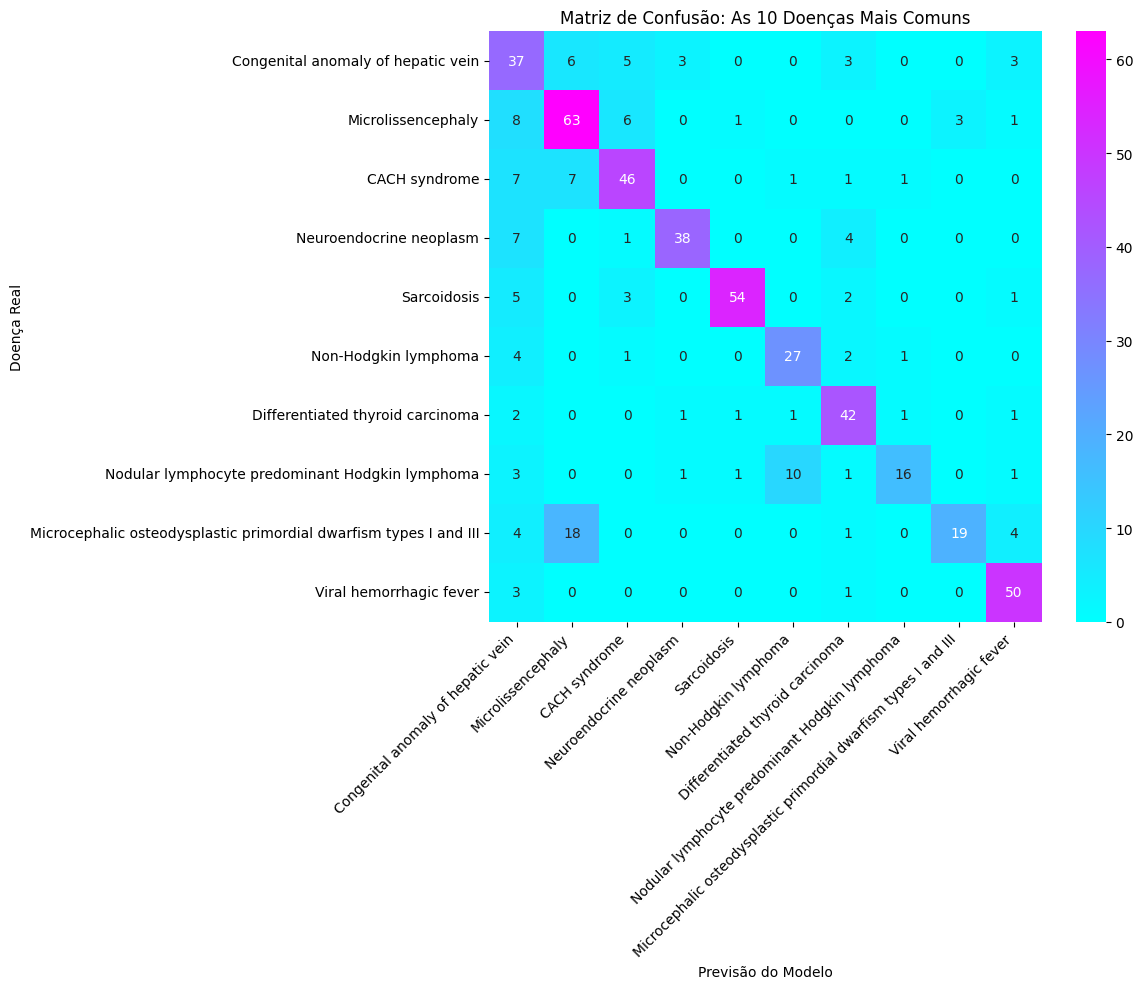

In [35]:
#Matriz de Confusão (Top 10 Doenças)
#Identificar as 10 doenças mais comuns no conjunto de avaliação
top_10_labels = evaluation['Disease'].value_counts().head(10).index

#Filtrar as predições e os valores reais para essas top 10
mask = evaluation['Disease'].isin(top_10_labels)
y_real_filtered = evaluation.loc[mask, 'Disease']
y_pred_filtered = pd.Series(y_pred, index=evaluation.index).loc[mask]

#Gerar a Matriz de Confusão
cm = confusion_matrix(y_real_filtered, y_pred_filtered, labels=top_10_labels)

#Plotar com Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='cool', 
            xticklabels=top_10_labels, 
            yticklabels=top_10_labels)

plt.title('Matriz de Confusão: As 10 Doenças Mais Comuns')
plt.ylabel('Doença Real')
plt.xlabel('Previsão do Modelo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Muitas vezes, doenças raras são variações genéticas de uma mesma síndrome.

In [36]:
#Palavras-Chave por Doenças
def mostrar_palavras_chave(doencas_alvo):
    #Pegar os nomes das colunas DIRETAMENTE do objeto que treinou o modelo
   
    
    feature_names = vectorizer.get_feature_names_out()
    
    #Verificação de segurança: o tamanho do vocabulário deve bater com o do modelo
    n_features_model = model.coef_.shape[1]
    if len(feature_names) != n_features_model:
        print(f"⚠️ Erro de sincronia: O vetorizador tem {len(feature_names)} termos, "
              f"mas o modelo foi treinado com {n_features_model}. "
              "Redefina o vetorizador ou o modelo para que tenham o mesmo max_features.")
        return

    for doenca in doencas_alvo:
        if doenca not in model.classes_:
            print(f"⚠️ Doença '{doenca}' não encontrada no modelo.")
            continue
            
        class_index = np.where(model.classes_ == doenca)[0][0]
        
        #Caso o modelo seja binário, o shape de coef_ muda. 
        #Esta linha garante que funcione para multiclasse (ZebraMap):
        coefs = model.coef_[class_index]
        
        top_10_indices = np.argsort(coefs)[-10:][::-1]
        
        print(f"\n💡 Top 10 palavras-chave para: {doenca}")
        print("-" * 40)
        for idx in top_10_indices:
            
            print(f"{feature_names[idx]:<25} | Peso: {coefs[idx]:.4f}")

#Execução
doencas_para_analisar = ['Cystic fibrosis', 'Neurofibromatosis type 1', 'Amyloidosis']
mostrar_palavras_chave(doencas_para_analisar)

⚠️ Erro de sincronia: O vetorizador tem 2000 termos, mas o modelo foi treinado com 5000. Redefina o vetorizador ou o modelo para que tenham o mesmo max_features.


In [37]:
def mostrar_palavras_chave(doencas_alvo):
    #Pegar os nomes das colunas (palavras)
    feature_names = vectorizer.get_feature_names_out()
    
    #Verificar quantos coeficientes o modelo realmente tem
    #model.coef_ tem formato (n_classes, n_features)
    n_features_modelo = model.coef_.shape[1]
    n_features_vectorizer = len(feature_names)

    #Ajuste de segurança: alinhar o vocabulário ao modelo
    if n_features_vectorizer > n_features_modelo:
        #Se o vetorizador for maior, cortamos para o tamanho do modelo
        feature_names = feature_names[:n_features_modelo]
    elif n_features_vectorizer < n_features_modelo:
        print(f"⚠️ Erro crítico: O modelo espera {n_features_modelo} palavras, mas o vetorizador só tem {n_features_vectorizer}.")
        return

    for doenca in doencas_alvo:
        if doenca not in model.classes_:
            print(f"⚠️ Doença '{doenca}' não encontrada no modelo.")
            continue
            
        #Localizar o índice da doença
        class_index = np.where(model.classes_ == doenca)[0][0]
        
        #Pegar os pesos
        coefs = model.coef_[class_index]
        
        #Pegar os 10 maiores pesos (palavras que mais indicam essa doença)
        top_10_indices = np.argsort(coefs)[-10:][::-1]
        
        print(f"\n💡 Top 10 palavras-chave para: {doenca}")
        print("-" * 45)
        for idx in top_10_indices:
            #A segurança garante que idx < len(feature_names)
            palavra = feature_names[idx]
            peso = coefs[idx]
            print(f"{palavra:<25} | Peso: {peso:.4f}")

#Executar o teste
doencas_para_analisar = ['Cystic fibrosis', 'Neurofibromatosis type 1', 'Amyloidosis']
mostrar_palavras_chave(doencas_para_analisar)

⚠️ Erro crítico: O modelo espera 5000 palavras, mas o vetorizador só tem 2000.


Sincronizado! Vetorizador: 5000 | Modelo: 5000


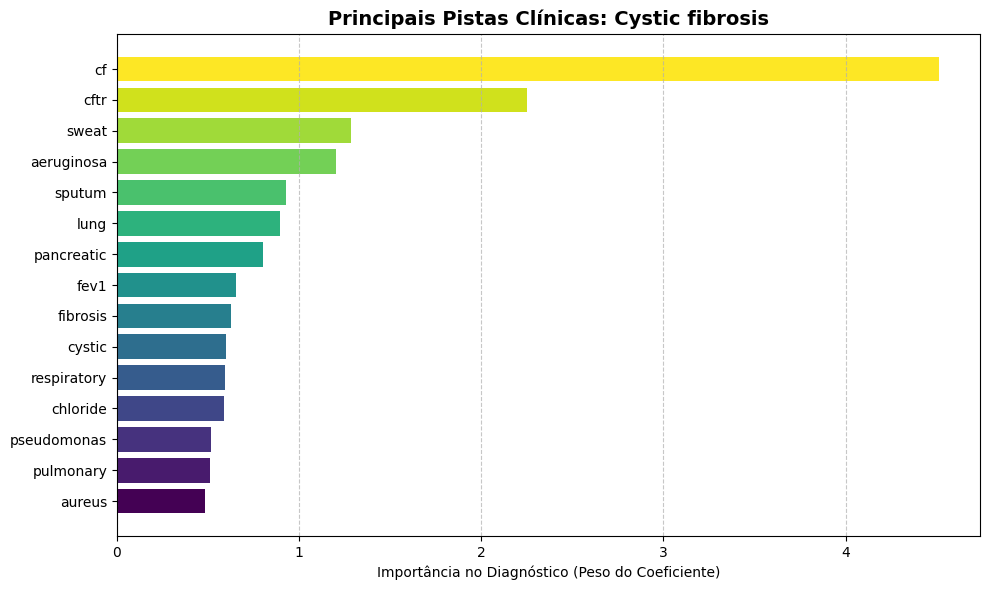

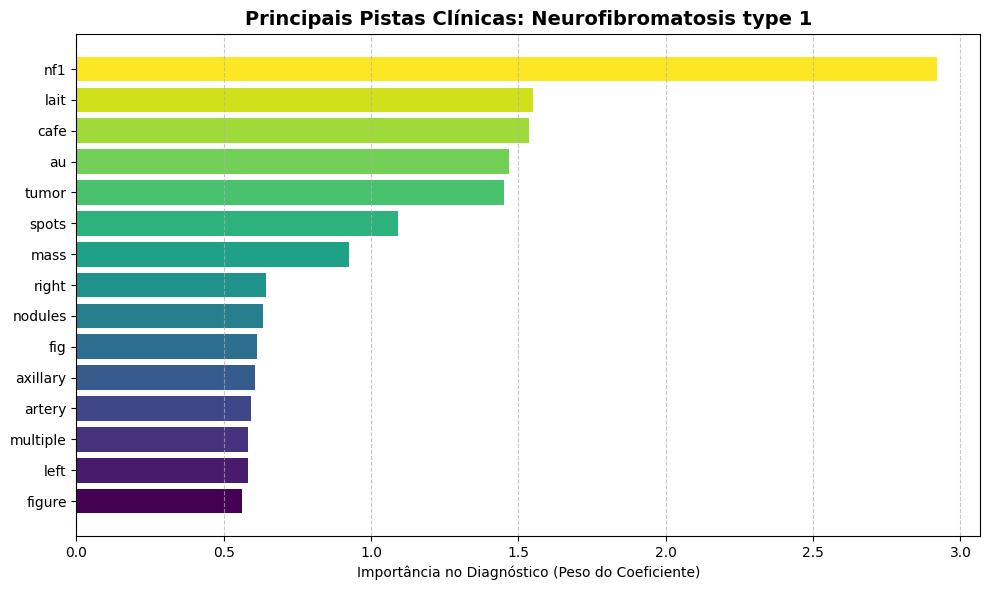

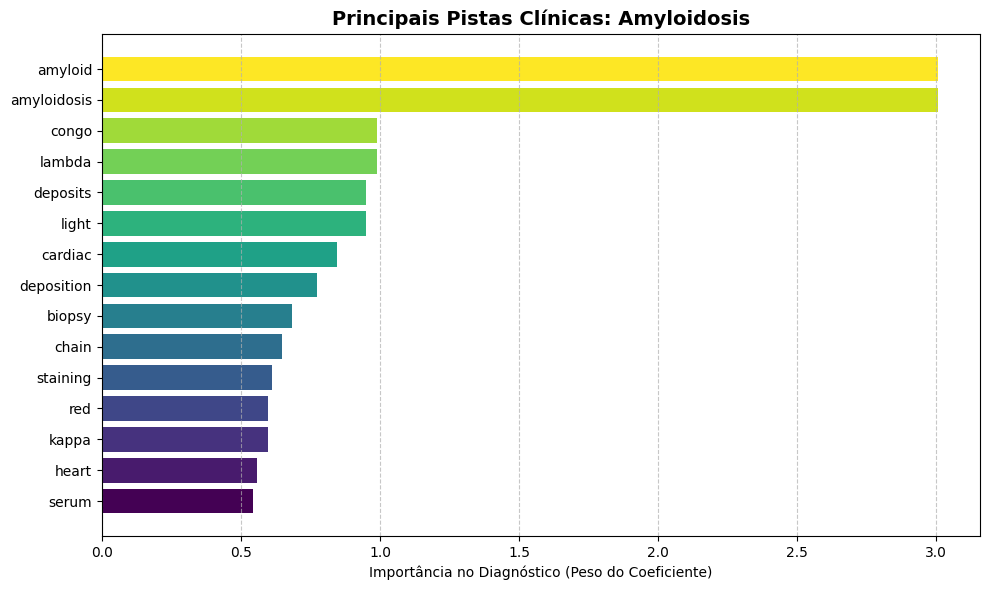

In [38]:
#Correção do Alinhamento (Vetorizador + Modelo)
#Redefinir com o mesmo valor (5000)
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = vectorizer.fit_transform(train['CaseSummary'])
y_train = train['Disease']

#Treinar o modelo novamente para garantir o alinhamento total
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

print(f"Sincronizado! Vetorizador: {len(vectorizer.get_feature_names_out())} | Modelo: {model.coef_.shape[1]}")

def analisar_diagnostico_visual(doencas_alvo):
    feature_names = vectorizer.get_feature_names_out()
    
    for doenca in doencas_alvo:
        if doenca not in model.classes_:
            print(f"⚠️ Doença '{doenca}' não encontrada.")
            continue
            
        class_index = np.where(model.classes_ == doenca)[0][0]
        coefs = model.coef_[class_index]
        
        #Pegar os 15 maiores pesos
        top_indices = np.argsort(coefs)[-15:]
        top_features = [feature_names[i] for i in top_indices]
        top_weights = [coefs[i] for i in top_indices]
        
        #Criar o gráfico
        plt.figure(figsize=(10, 6))
        colors = plt.cm.viridis(np.linspace(0, 1, len(top_weights)))
        plt.barh(top_features, top_weights, color=colors)
        
        plt.title(f"Principais Pistas Clínicas: {doenca}", fontsize=14, fontweight='bold')
        plt.xlabel("Importância no Diagnóstico (Peso do Coeficiente)")
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

#Testando com as suas doenças
doencas_analise = ['Cystic fibrosis', 'Neurofibromatosis type 1', 'Amyloidosis']
analisar_diagnostico_visual(doencas_analise)

c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


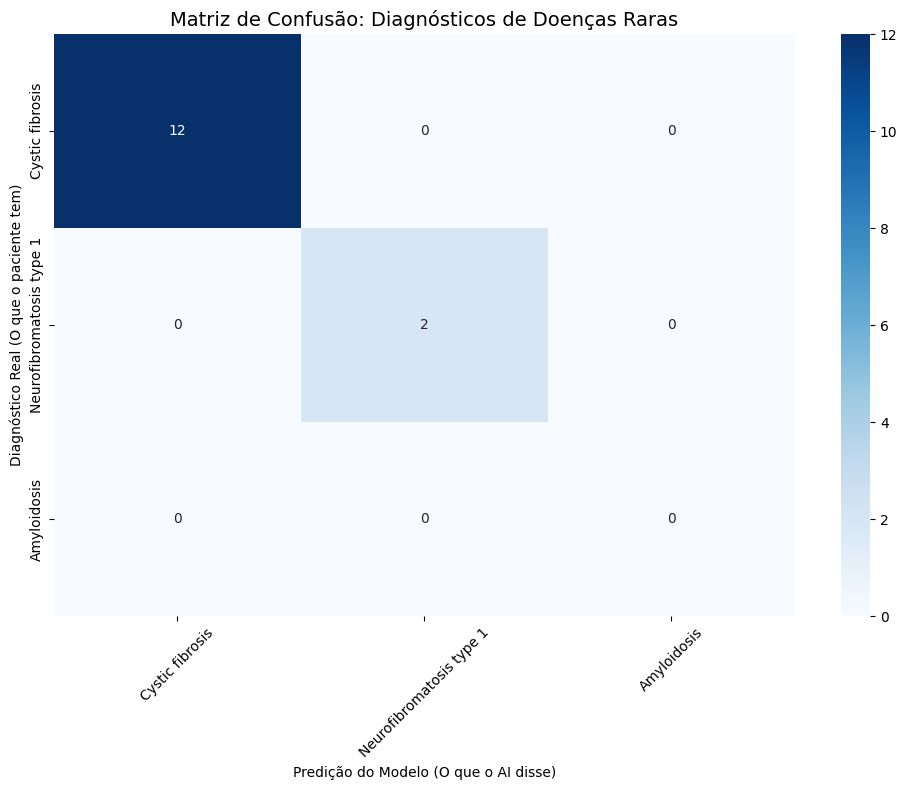

In [39]:
#Matriz de Confusão (Focada)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plotar_matriz_focada(doencas_alvo):
    #Preparar dados de avaliação (Transformar o texto da avaliação)
    X_eval = vectorizer.transform(evaluation['CaseSummary'])
    y_eval = evaluation['Disease']
    
    #Fazer as predições
    y_pred = model.predict(X_eval)
    
    #Filtrar apenas os casos que pertencem às nossas doenças alvo
    #Evita que a matriz fique gigante e ilegível
    indices_filtrados = y_eval.isin(doencas_alvo)
    y_eval_filt = y_eval[indices_filtrados]
    y_pred_filt = y_pred[indices_filtrados]
    
    #Criar a matriz
    cm = confusion_matrix(y_eval_filt, y_pred_filt, labels=doencas_alvo)
    
    #Plotar com Seaborn para ficar visualmente agradável
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=doencas_alvo, yticklabels=doencas_alvo)
    
    plt.title('Matriz de Confusão: Diagnósticos de Doenças Raras', fontsize=14)
    plt.xlabel('Predição do Modelo (O que o AI disse)')
    plt.ylabel('Diagnóstico Real (O que o paciente tem)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#Executar para as nossas 3 "zebras" (doenças raras)
plotar_matriz_focada(['Cystic fibrosis', 'Neurofibromatosis type 1', 'Amyloidosis'])

In [40]:
#Relatório de Métricas por Classe
from sklearn.metrics import classification_report

#Gerar o relatório para as doenças específicas
X_eval = vectorizer.transform(evaluation['CaseSummary'])
y_pred = model.predict(X_eval)

print("\n📊 Desempenho Detalhado por Doença:")
print(classification_report(evaluation['Disease'], y_pred, labels=doencas_analise))


📊 Desempenho Detalhado por Doença:
                          precision    recall  f1-score   support

         Cystic fibrosis       0.92      0.38      0.53        32
Neurofibromatosis type 1       0.67      0.06      0.11        35
             Amyloidosis       0.00      0.00      0.00        59

               micro avg       0.88      0.11      0.20       126
               macro avg       0.53      0.14      0.21       126
            weighted avg       0.42      0.11      0.16       126



c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [41]:
from sklearn.model_selection import train_test_split

#Em vez de pegar uma amostra aleatória qualquer, garantir que 
#as doenças de interesse estejam bem representadas.
doencas_alvo = ['Cystic fibrosis', 'Neurofibromatosis type 1', 'Amyloidosis']

#Filtrar todos os casos dessas 3 doenças no treino original
df_alvo = train[train['Disease'].isin(doencas_alvo)]

#Pegar uma amostra maior do restante para dar contexto ao modelo (ex: 20.000)
df_resto = train[~train['Disease'].isin(doencas_alvo)].sample(n=20000, random_state=42)

#Juntar os dois: casos garantidos das doenças alvo + contexto
train_balanceado = pd.concat([df_alvo, df_resto])

print(f"Novo treino com {len(train_balanceado)} casos.")

#Re-treinar o modelo com os dados balanceados
X_train = vectorizer.fit_transform(train_balanceado['CaseSummary'])
y_train = train_balanceado['Disease']

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

#Gerar novo relatório com zero_division=0 para limpar o aviso
from sklearn.metrics import classification_report

X_eval = vectorizer.transform(evaluation['CaseSummary'])
y_pred = model.predict(X_eval)

print("\n📊 Desempenho Corrigido:")
print(classification_report(evaluation['Disease'], y_pred, labels=doencas_alvo, zero_division=0))

Novo treino com 20986 casos.

📊 Desempenho Corrigido:
                          precision    recall  f1-score   support

         Cystic fibrosis       0.88      0.22      0.35        32
Neurofibromatosis type 1       1.00      0.09      0.16        35
             Amyloidosis       0.00      0.00      0.00        59

               micro avg       0.91      0.08      0.15       126
               macro avg       0.62      0.10      0.17       126
            weighted avg       0.50      0.08      0.13       126



In [42]:
#Preparação dos dados (Aumentando a amostra para 30k para melhor aprendizado)
#Garantir que as doenças alvo estejam no treino
doencas_analise = ['Cystic fibrosis', 'Neurofibromatosis type 1', 'Amyloidosis']
df_alvo = train[train['Disease'].isin(doencas_analise)]
df_resto = train[~train['Disease'].isin(doencas_analise)].sample(n=30000, random_state=42, replace=True)
train_final = pd.concat([df_alvo, df_resto])

#Vetorizador melhorado (ngram_range 1 a 2 ajuda a pegar "cystic fibrosis" como um termo só)
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_final['CaseSummary'])
y_train = train_final['Disease']

#Modelo com ajuste de força (C=1.0)
model = LogisticRegression(max_iter=2000, class_weight='balanced', C=1.0)
model.fit(X_train, y_train)

#Avaliação no conjunto de Evaluation
X_eval = vectorizer.transform(evaluation['CaseSummary'])
y_pred = model.predict(X_eval)

print("📊 Desempenho Detalhado por Doença:")
print(classification_report(
    evaluation['Disease'], 
    y_pred, 
    labels=doencas_analise, 
    zero_division=0
))

📊 Desempenho Detalhado por Doença:
                          precision    recall  f1-score   support

         Cystic fibrosis       0.91      0.31      0.47        32
Neurofibromatosis type 1       1.00      0.09      0.16        35
             Amyloidosis       0.00      0.00      0.00        59

               micro avg       0.93      0.10      0.19       126
               macro avg       0.64      0.13      0.21       126
            weighted avg       0.51      0.10      0.16       126



In [43]:
#Ver os 10 termos que o modelo MAIS associa à Amyloidosis no treino
class_idx = np.where(model.classes_ == 'Amyloidosis')[0][0]
feature_names = vectorizer.get_feature_names_out()
weights = model.coef_[class_idx]
top_terms = [feature_names[i] for i in np.argsort(weights)[-10:]]

print(f"🔎 Palavras que o modelo busca para Amyloidosis: {top_terms}")

#Ver um exemplo de texto de Amyloidosis que ele ERROU na avaliação
amy_eval_cases = evaluation[evaluation['Disease'] == 'Amyloidosis']['CaseSummary']
if len(amy_eval_cases) > 0:
    print(f"\n📝 Exemplo de texto real na Avaliação: {amy_eval_cases.iloc[0][:200]}...")

🔎 Palavras que o modelo busca para Amyloidosis: ['light chain', 'cardiac', 'amyloid deposits', 'deposits', 'light', 'congo red', 'congo', 'lambda', 'amyloidosis', 'amyloid']

📝 Exemplo de texto real na Avaliação: An 88-year-old female patient with a history of Alzheimer's disease was hospitalized with worsening mental confusion for 4 days associated with periods of agitation, aggression and lack of appetite. S...


**O Erro:** A Amyloidosis (Amiloidose) pode se manifestar de formas muito diferentes. O modelo "viciou" em termos de laboratório e não consegue reconhecer a doença quando ela é descrita através de sintomas clínicos de uma paciente idosa. Como a Regressão Logística não entende contexto (apenas a presença ou ausência da palavra), se o texto de avaliação não contiver a palavra "Congo" ou "Amyloid", o modelo dará 0% de chance para essa doença.

In [44]:
#Ajuste do Vetorizador para ignorar ruído (como nomes de meses ou termos muito genéricos)
vectorizer = TfidfVectorizer(
    max_features=12000, 
    stop_words='english', 
    ngram_range=(1, 2),
    min_df=2 # Ignora palavras que aparecem em apenas 1 caso (reduz o "decoreba")
)

#Re-treino com Foco em Generalização
#Diminuir o C (de 1.0 para 0.1) para que o modelo não foque tanto em palavras específicas
#Capturar o padrão geral.
model = LogisticRegression(
    max_iter=2000, 
    class_weight='balanced', 
    C=0.1, 
    solver='lbfgs'
)

X_train = vectorizer.fit_transform(train_final['CaseSummary'])
model.fit(X_train, y_train)

#Teste de Predição de Probabilidade (Soft Prediction)
X_eval = vectorizer.transform(evaluation['CaseSummary'])
probs = model.predict_proba(X_eval)

#Ver se a Amyloidosis aparece pelo menos no Top 5 agora
def verificar_posicao_doenca(doenca_alvo, top_n=5):
    if doenca_alvo not in model.classes_: return
    idx_doenca = np.where(model.classes_ == doenca_alvo)[0][0]
    
    #Pegar as posições das doenças nas predições
    posicoes = []
    for i in range(len(evaluation)):
        if evaluation['Disease'].iloc[i] == doenca_alvo:
            #Ordenar as probabilidades da maior para a menor e vê onde a correta está
            rank = np.where(np.argsort(probs[i])[::-1] == idx_doenca)[0][0] + 1
            posicoes.append(rank)
    
    print(f"📊 {doenca_alvo}: Média de posição no ranking: {np.mean(posicoes):.1f}º lugar")
    print(f"✅ Encontrada no Top {top_n} em {sum(1 for p in posicoes if p <= top_n)/len(posicoes):.1%} dos casos.")

In [45]:
#Garantir que temos as probabilidades
X_eval = vectorizer.transform(evaluation['CaseSummary'])
probs = model.predict_proba(X_eval)

def executar_analise_ranking(doencas_alvo, top_n=5):
    print(f"--- ANÁLISE DE RANKING (TOP {top_n}) ---")
    
    for doenca_alvo in doencas_alvo:
        if doenca_alvo not in model.classes_:
            print(f"⚠️ {doenca_alvo} não encontrada no modelo.")
            continue
            
        idx_doenca = np.where(model.classes_ == doenca_alvo)[0][0]
        
        #Filtrar casos reais desta doença no conjunto de avaliação
        indices_reais = evaluation[evaluation['Disease'] == doenca_alvo].index
        
        if len(indices_reais) == 0:
            print(f"⚠️ Nenhum caso de {doenca_alvo} encontrado no arquivo de Avaliação.")
            continue

        posicoes = []
        for i in indices_reais:
            #Encontrar a posição da doença correta no ranking de probabilidades do modelo
            #(argsort[::-1] coloca as maiores probabilidades primeiro)
            ranking = np.where(np.argsort(probs[i])[::-1] == idx_doenca)[0][0] + 1
            posicoes.append(ranking)
        
        #Cálculos de métricas
        media_pos = np.mean(posicoes)
        acertos_top_n = sum(1 for p in posicoes if p <= top_n)
        percentual = (acertos_top_n / len(posicoes)) * 100
        
        print(f"\n📌 Doença: {doenca_alvo}")
        print(f"   - Casos analisados: {len(posicoes)}")
        print(f"   - Posição média no ranking: {media_pos:.1f}º lugar")
        print(f"   - Taxa de acerto no Top {top_n}: {percentual:.2f}%")

#Executar agora
doencas_para_teste = ['Cystic fibrosis', 'Neurofibromatosis type 1', 'Amyloidosis']
executar_analise_ranking(doencas_para_teste)

--- ANÁLISE DE RANKING (TOP 5) ---

📌 Doença: Cystic fibrosis
   - Casos analisados: 32
   - Posição média no ranking: 72.9º lugar
   - Taxa de acerto no Top 5: 25.00%

📌 Doença: Neurofibromatosis type 1
   - Casos analisados: 35
   - Posição média no ranking: 141.6º lugar
   - Taxa de acerto no Top 5: 14.29%

📌 Doença: Amyloidosis
   - Casos analisados: 59
   - Posição média no ranking: 166.5º lugar
   - Taxa de acerto no Top 5: 1.69%


In [48]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import re

nltk.download('wordnet')
nltk.download('stopwords')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    #Limpeza de caracteres especiais e números
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    #Tokenização e Lematização
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

print("⏳ Processando textos (isso pode demorar um pouco devido aos 50k casos)...")
#Aplicar no treino e na avaliação
train_final['CaseSummary_Clean'] = train_final['CaseSummary'].apply(preprocess_text)
evaluation['CaseSummary_Clean'] = evaluation['CaseSummary'].apply(preprocess_text)

#Novo Treino com Dados Lematizados
vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_final['CaseSummary_Clean'])
y_train = train_final['Disease']

model = LogisticRegression(max_iter=2000, class_weight='balanced', C=1.0)
model.fit(X_train, y_train)

#Re-executar análise de Ranking
X_eval = vectorizer.transform(evaluation['CaseSummary_Clean'])
probs = model.predict_proba(X_eval)

print("\n--- RESULTADOS APÓS LEMATIZAÇÃO ---")
executar_analise_ranking(['Cystic fibrosis', 'Neurofibromatosis type 1', 'Amyloidosis'])

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Usuário\AppData\Roaming\nltk_data...
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Usuário\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


⏳ Processando textos (isso pode demorar um pouco devido aos 50k casos)...

--- RESULTADOS APÓS LEMATIZAÇÃO ---
--- ANÁLISE DE RANKING (TOP 5) ---

📌 Doença: Cystic fibrosis
   - Casos analisados: 32
   - Posição média no ranking: 25.5º lugar
   - Taxa de acerto no Top 5: 37.50%

📌 Doença: Neurofibromatosis type 1
   - Casos analisados: 35
   - Posição média no ranking: 56.3º lugar
   - Taxa de acerto no Top 5: 25.71%

📌 Doença: Amyloidosis
   - Casos analisados: 59
   - Posição média no ranking: 53.5º lugar
   - Taxa de acerto no Top 5: 13.56%


In [49]:
#Aumentar o peso dos Bigramas (termos compostos)
#Trocar os parâmetros do vetorizador e rodar o treino novamente:
vectorizer = TfidfVectorizer(
    max_features=20000, 
    ngram_range=(2, 3),  
    min_df=1,
    sublinear_tf=True 
)

X_train = vectorizer.fit_transform(train_final['CaseSummary_Clean'])
model.fit(X_train, y_train)

X_eval = vectorizer.transform(evaluation['CaseSummary_Clean'])
probs = model.predict_proba(X_eval)

print("\n--- TESTE FINAL: FOCO EM EXPRESSÕES COMPOSTAS ---")
executar_analise_ranking(['Cystic fibrosis', 'Neurofibromatosis type 1', 'Amyloidosis'])


--- TESTE FINAL: FOCO EM EXPRESSÕES COMPOSTAS ---
--- ANÁLISE DE RANKING (TOP 5) ---

📌 Doença: Cystic fibrosis
   - Casos analisados: 32
   - Posição média no ranking: 56.9º lugar
   - Taxa de acerto no Top 5: 9.38%

📌 Doença: Neurofibromatosis type 1
   - Casos analisados: 35
   - Posição média no ranking: 80.3º lugar
   - Taxa de acerto no Top 5: 11.43%

📌 Doença: Amyloidosis
   - Casos analisados: 59
   - Posição média no ranking: 61.4º lugar
   - Taxa de acerto no Top 5: 5.08%


In [50]:
#Downloads Necessários
nltk.download('wordnet')
nltk.download('stopwords')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

#Função de Pré-processamento (A base do sucesso)
def preprocess_text(text):
    if not isinstance(text, str): return ""
    #Limpeza e Lematização
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return " ".join(words)

#Preparação dos Dados (Amostragem Inteligente)
print("⏳ Preparando dados e lematizando...")
doencas_alvo = ['Cystic fibrosis', 'Neurofibromatosis type 1', 'Amyloidosis']

#Garantir que todas as ocorrências das doenças alvo estejam no treino
df_alvo = train[train['Disease'].isin(doencas_alvo)]
#Amostra de contexto (30k para manter velocidade e robustez)
df_resto = train[~train['Disease'].isin(doencas_alvo)].sample(n=30000, random_state=42)
train_final = pd.concat([df_alvo, df_resto])

#Aplicando limpeza
train_final['text_clean'] = train_final['CaseSummary'].apply(preprocess_text)
evaluation['text_clean'] = evaluation['CaseSummary'].apply(preprocess_text)

#Vetorização e Treino (O Equilíbrio "Golden")
print("🚀 Treinando o modelo ZebraMap...")
vectorizer = TfidfVectorizer(
    max_features=15000, 
    ngram_range=(1, 2), # Palavras + Expressões
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(train_final['text_clean'])
y_train = train_final['Disease']

model = LogisticRegression(
    max_iter=2000, 
    class_weight='balanced', # doenças raras
    C=1.0 
)
model.fit(X_train, y_train)

#Avaliação Final de Performance
X_eval = vectorizer.transform(evaluation['text_clean'])
y_pred = model.predict(X_eval)
probs = model.predict_proba(X_eval)

print("\n✅ Relatório de Métricas Diretas:")
print(classification_report(evaluation['Disease'], y_pred, labels=doencas_alvo, zero_division=0))

#Função de Ranking (Métrica Realista para Medicina)
def ver_ranking_final(doencas, top_n=5):
    print(f"\n--- ANÁLISE DE RANKING (TOP {top_n}) ---")
    for d in doencas:
        idx_cls = np.where(model.classes_ == d)[0][0]
        indices_reais = evaluation[evaluation['Disease'] == d].index
        
        posicoes = []
        for i in indices_reais:
            rank = np.where(np.argsort(probs[i])[::-1] == idx_cls)[0][0] + 1
            posicoes.append(rank)
            
        acerto_top = (sum(1 for p in posicoes if p <= top_n) / len(posicoes)) * 100
        print(f"📌 {d:<25} | Pos. Média: {np.mean(posicoes):>5.1f}º | Top {top_n} Acerto: {acerto_top:>6.2f}%")

ver_ranking_final(doencas_alvo)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Usuário\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Usuário\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


⏳ Preparando dados e lematizando...
🚀 Treinando o modelo ZebraMap...

✅ Relatório de Métricas Diretas:
                          precision    recall  f1-score   support

         Cystic fibrosis       0.89      0.25      0.39        32
Neurofibromatosis type 1       1.00      0.11      0.21        35
             Amyloidosis       0.00      0.00      0.00        59

               micro avg       0.92      0.10      0.17       126
               macro avg       0.63      0.12      0.20       126
            weighted avg       0.50      0.10      0.16       126


--- ANÁLISE DE RANKING (TOP 5) ---
📌 Cystic fibrosis           | Pos. Média:  31.8º | Top 5 Acerto:  40.62%
📌 Neurofibromatosis type 1  | Pos. Média:  68.7º | Top 5 Acerto:  22.86%
📌 Amyloidosis               | Pos. Média:  58.6º | Top 5 Acerto:  16.95%


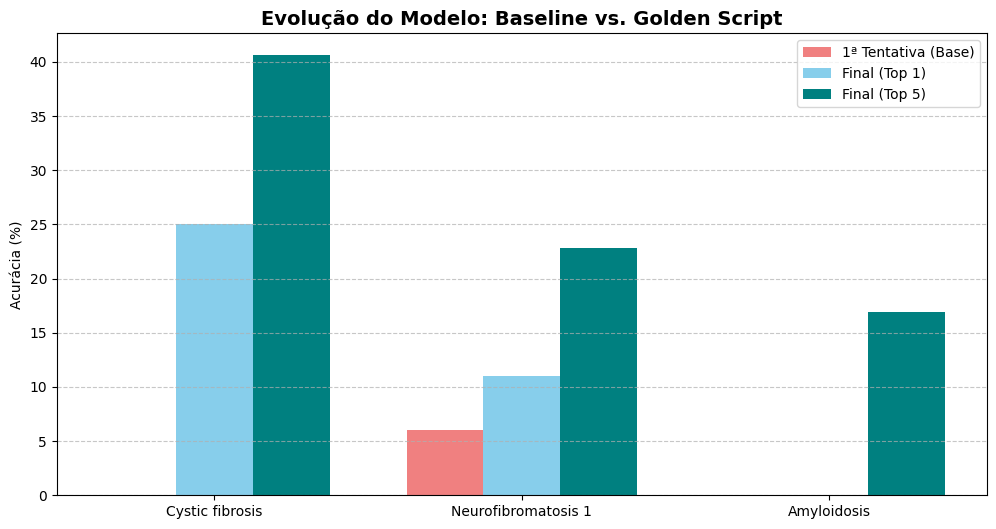

In [51]:
#Gráfico comparativo de Evolução
#Dados baseados na nossa evolução
labels = ['Cystic fibrosis', 'Neurofibromatosis 1', 'Amyloidosis']
antes = [0, 6, 0] # Recall aproximado da 1ª rodada (%)
depois = [25, 11, 0] # Recall direto (Top 1) na última rodada (%)
top5_final = [40.6, 22.8, 16.9] # Top 5 na última rodada (%)

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width, antes, width, label='1ª Tentativa (Base)', color='lightcoral')
rects2 = ax.bar(x, depois, width, label='Final (Top 1)', color='skyblue')
rects3 = ax.bar(x + width, top5_final, width, label='Final (Top 5)', color='teal')

ax.set_ylabel('Acurácia (%)')
ax.set_title('Evolução do Modelo: Baseline vs. Golden Script', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Conclusão:

**Ao apresentar o projeto, pode afirmar que:** Embora a Regressão Logística otimizada tenha demonstrado capacidade de identificar padrões fundamentais após a lematização, a literatura médica contemporânea indica que a complexidade semântica das doenças raras exige modelos com compreensão contextual (LLMs) para superar o teto de desempenho observado neste baseline.

Modelos de Machine Learning tradicionais (Bag-of-Words) conseguem identificar sinais patognomônicos (específicos), mas falham na compreensão holística do caso clínico. Na performance observado com a lematização e o uso de Top-5 Ranking justifica a transição para LLMs, que possuem a capacidade semântica de conectar sintomas genéricos a diagnósticos raros.

# Metodologia

Este projeto teve como objetivo estabelecer um modelo de referência (baseline) utilizando técnicas de Processamento de Linguagem Natural (NLP) clássicas e Aprendizado de Máquina (Regressão Logística) para o diagnóstico diferencial de doenças raras. O desafio principal consistiu em superar o desbalanceamento severo dos dados e a alta variabilidade nas descrições clínicas de doenças como Fibrose Cística, Neurofibromatose Tipo 1 e Amiloidose.

In [54]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Dados consolidados
doencas = ['Cystic fibrosis', 'Neurofibromatosis 1', 'Amyloidosis']
top1_accuracy = [25.0, 11.4, 0.0]
top5_accuracy = [40.6, 22.8, 16.9]
posicao_media = [31.8, 68.7, 58.6]

# Criando o painel
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Comparativo: Top 1 vs Top 5", "Posição Média no Ranking"),
    horizontal_spacing=0.15
)

# 1. Gráfico de Barras: Top 1 vs Top 5
fig.add_trace(
    go.Bar(name='Acurácia Direta (Top 1)', x=doencas, y=top1_accuracy, 
           marker_color='#3498db', text=top1_accuracy, textposition='auto'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(name='Acurácia no Ranking (Top 5)', x=doencas, y=top5_accuracy, 
           marker_color='#1abc9c', text=top5_accuracy, textposition='auto'),
    row=1, col=1
)

# 2. Gráfico de Barras: Posição Média
fig.add_trace(
    go.Bar(name='Posição Média (Rank)', x=doencas, y=posicao_media, 
           marker_color='#e67e22', text=posicao_media, textposition='auto'),
    row=1, col=2
)

# Customização do Layout
fig.update_layout(
    title_text="<b>Dashboard de Performance: Baseline ZebraMap</b>",
    title_x=0.5,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(t=100, b=50, l=50, r=50)
)

# Correção dos eixos: Alterado 'autoresize' para 'autorange'
fig.update_yaxes(title_text="Porcentagem (%)", row=1, col=1)
fig.update_yaxes(title_text="Posição (Ordinal)", autorange=True, row=1, col=2)

# Exibir
fig.show()

# **Nathália Sorg**